# TIME SERIES FORECASTING MODEL COMPARISON

## 1. Introduction

This project focuses on comparing different approaches for time series forecasting using **daily weather data** collected from the **Open-Meteo API**. The dataset contains historical temperature information from my hometown, **Kocaeli, Turkey**.

The analysis uses data between 2010 and 2025. The year 2025 is separated as the test period in order to evaluate forecasting performance on unseen future data.

The main objective of this study is to compare the R2 performance of different forecasting approaches, including:

* baseline methods,
* machine learning models,
* deep learning models,
* feature engineered solutions.

## 2. Data Preparation

### 2.1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### 2.2. Load Dataset

In [2]:
df_main = pd.read_csv("kocaeli_2010_2025.csv", parse_dates=["date"])

### 2.3. Global Configuration

In [3]:
ACTUAL_COLOR = "#87CEEB"
PRED_COLOR = "#FF0000"
TEST_DAYS = 365
LAG_DAYS = 365
VAL_RATIO = 0.1
TARGET_COL = 0

### 2.4. Visualization Helper Function

In [4]:
def plot_predictions(y_true, y_pred, title, ylabel):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, "-o", label="Actual", color=ACTUAL_COLOR)
    plt.plot(y_pred, "-*", label="Prediction", color=PRED_COLOR)
    plt.title(title)
    plt.xlabel("Test Period")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid()
    plt.show()

### 2.5. Data Scaling

**Univariate Data Scaling**

In [5]:
df_uni = df_main[df_main['date'].dt.year != 2026].copy()
df_uni = df_uni.drop(columns=['date', 'temp_max', 'temp_min'])
scaler_uni = StandardScaler()
scaler_uni.fit(df_uni.iloc[:-TEST_DAYS, :])
df_scaled_uni = scaler_uni.transform(df_uni)

**Multivariate Data Scaling**

In [6]:
df_multi = df_main[df_main['date'].dt.year != 2026].copy()
df_multi = df_multi[['temp_mean', 'temp_min', 'temp_max']].copy()
scaler_multi = StandardScaler()
scaler_multi.fit(df_multi.iloc[:-TEST_DAYS, :])
df_scaled_multi = scaler_multi.transform(df_multi)

## 3. Historical Daily Average Baseline

Before learning machine learning and deep learning methods, this was the forecasting approach I used most often in real life.

The idea is simple: calculate the historical average temperature for each day of the year using past observations, then use that average as the prediction for the same day in the future.

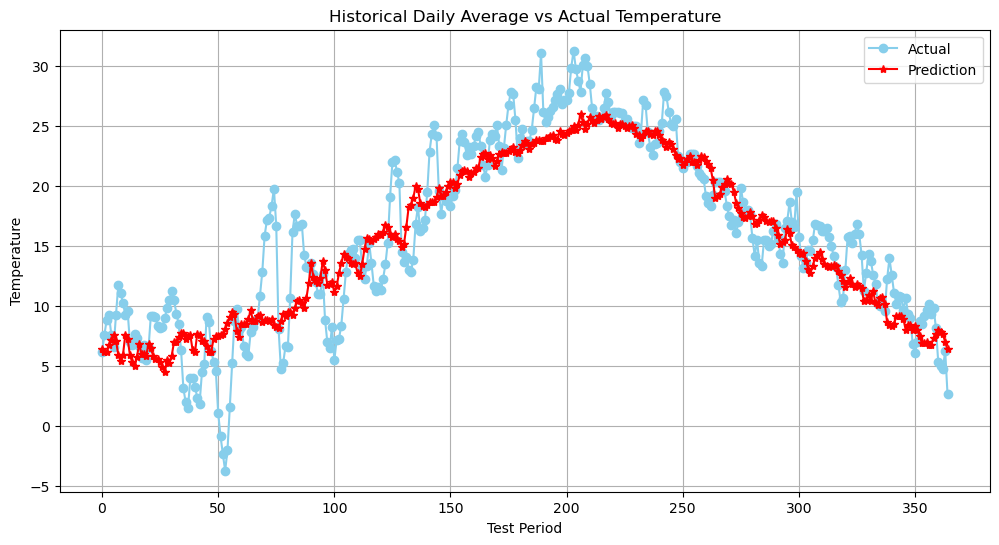

Historical Daily Average R2 Score: 0.814
CPU times: user 75.4 ms, sys: 5.42 ms, total: 80.8 ms
Wall time: 84.1 ms


In [7]:
%%time

df_avg = df_main.copy()
df_avg = df_avg[df_avg['date'].dt.year != 2026].copy()
df_avg = df_avg.sort_values("date").reset_index(drop=True)

test_data = df_avg.iloc[-TEST_DAYS:].copy()
train_data = df_avg.iloc[:-TEST_DAYS].copy()

train_data['dayofyear'] = train_data['date'].dt.dayofyear
test_data['dayofyear'] = test_data['date'].dt.dayofyear

historical_daily_avg = (
    train_data
    .groupby('dayofyear')['temp_mean']
    .mean()
    .reset_index()
    .rename(columns={'temp_mean': 'historical_daily_avg'}))

test_comparison = test_data.merge(historical_daily_avg, on='dayofyear', how='left')

y_test_avg = test_comparison['temp_mean'].values
y_pred_avg = test_comparison['historical_daily_avg'].values

daily_avg_r2 = r2_score(y_test_avg, y_pred_avg)

plot_predictions(
    y_test_avg,
    y_pred_avg,
    "Historical Daily Average vs Actual Temperature",
    "Temperature")

print("Historical Daily Average R2 Score:", round(daily_avg_r2, 4))

## 4. Univariate One Step Ahead Forecasting

The first forecasting approach uses only past average temperature values to predict the next day. The idea is this: "can future temperature behavior be learned using only its own historical pattern?"

Please remember; the models were trained using historical observations between 2010 and 2024, while the full year of 2025 was used as the test period to evaluate forecasting performance on unseen data.

Two different approaches were compared:

* Gradient Boosting
* LSTM Neural Network

### 4.1. Gradient Boosting

X shape: (5475, 365)
y shape: (5475,)


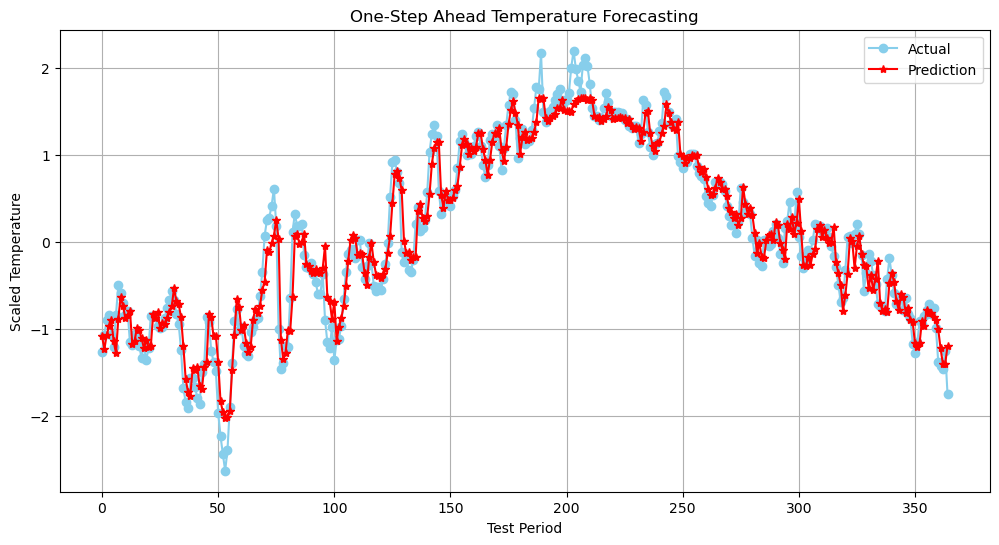

Univariate Gradient Boosting R2 Score: 0.95
CPU times: user 21.4 s, sys: 50.2 ms, total: 21.5 s
Wall time: 21.5 s


In [8]:
%%time

def preprocess(data, lag=365):
    X = []
    y = []

    for i in range(len(data) - lag):
        X.append(data[i:i + lag])
        y.append(data[i + lag])

    return np.array(X), np.array(y)

X, y = preprocess(df_scaled_uni[:, 0], lag=LAG_DAYS)

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train = X[:-TEST_DAYS]
y_train = y[:-TEST_DAYS]

X_test = X[-TEST_DAYS:]
y_test = y[-TEST_DAYS:]

mdl = GradientBoostingRegressor(random_state=42)

mdl.fit(X_train, y_train)

y_pred = mdl.predict(X_test)

plot_predictions(
    y_test,
    y_pred,
    "One-Step Ahead Temperature Forecasting",
    "Scaled Temperature")

gbr_uni_r2 = r2_score(y_test, y_pred)
print("Univariate Gradient Boosting R2 Score:", round(gbr_uni_r2, 4))

### 4.2. LSTM

X shape: (5475, 365, 1)
y shape: (5475,)
Train shape: (4599, 365, 1)
Validation shape: (511, 365, 1)
Test shape: (365, 365, 1)
Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - loss: 0.2471 - val_loss: 0.0701
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - loss: 0.0746 - val_loss: 0.0499
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - loss: 0.0575 - val_loss: 0.0503
Epoch 4/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - loss: 0.0551 - val_loss: 0.0498
Epoch 5/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - loss: 0.0546 - val_loss: 0.0501
Epoch 6/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0544 - val_loss: 0.0503
Epoch 7/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0541 - val_loss: 0.0507
Epoch 8/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - loss: 0.0540 - val_loss: 0.0513
Epoch 9/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - loss: 0.0537 - val_loss: 0.0517
Epoch 10/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - loss: 0.0536 -

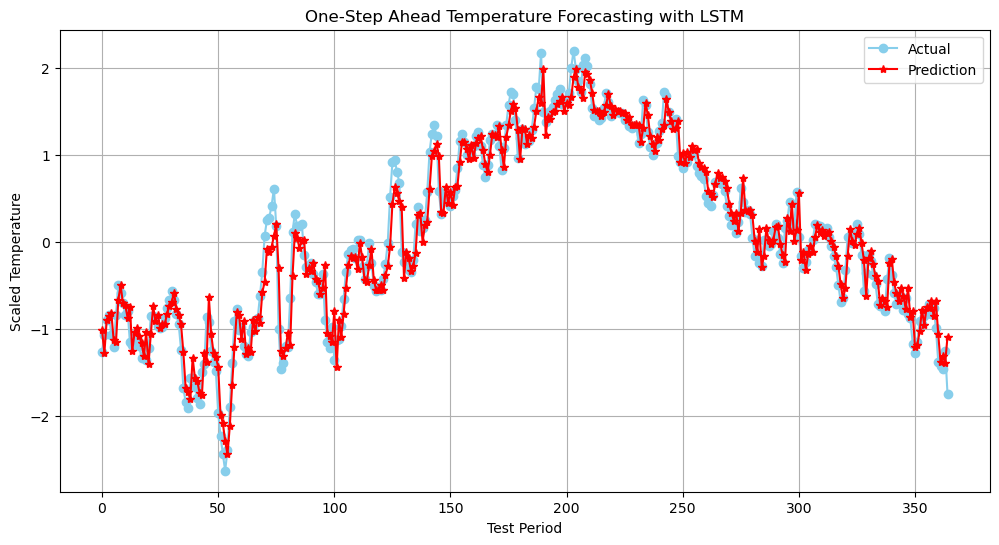

Univariate LSTM R2 Score: 0.9611
CPU times: user 3min 34s, sys: 33.3 s, total: 4min 7s
Wall time: 2min 29s


In [9]:
%%time

tf.random.set_seed(42)
np.random.seed(42)

X_lstm, y_lstm = preprocess(df_scaled_uni[:, 0], lag=LAG_DAYS)

X_lstm = X_lstm[..., np.newaxis]

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

X_train_full_lstm = X_lstm[:-TEST_DAYS]
y_train_full_lstm = y_lstm[:-TEST_DAYS]

X_test_lstm = X_lstm[-TEST_DAYS:]
y_test_lstm = y_lstm[-TEST_DAYS:]

val_size = int(len(X_train_full_lstm) * VAL_RATIO)

X_train_lstm = X_train_full_lstm[:-val_size]
y_train_lstm = y_train_full_lstm[:-val_size]

X_val_lstm = X_train_full_lstm[-val_size:]
y_val_lstm = y_train_full_lstm[-val_size:]

print("Train shape:", X_train_lstm.shape)
print("Validation shape:", X_val_lstm.shape)
print("Test shape:", X_test_lstm.shape)

mdl_lstm = keras.Sequential([
    layers.Input(shape=X_train_lstm.shape[1:]),
    layers.LSTM(128),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="linear")])

mdl_lstm.compile(
    optimizer="adam",
    loss="mse")

history_lstm = mdl_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=10,
    batch_size=32,
    verbose=1)

y_pred_lstm = mdl_lstm.predict(X_test_lstm).ravel()

plot_predictions(
    y_test_lstm,
    y_pred_lstm,
    "One-Step Ahead Temperature Forecasting with LSTM",
    "Scaled Temperature")

lstm_uni_r2 = r2_score(y_test_lstm, y_pred_lstm)
print("Univariate LSTM R2 Score:", round(lstm_uni_r2, 4))

## 5. Multivariate One Step Ahead Forecasting

After testing single-variable forecasting, I **expanded the input data** by adding minimum and maximum temperature values together with average temperature.

The goal was to see if **adding more weather-related variables could improve forecasting performance**.

Again, the models were trained using historical observations between 2010 and 2024, while the full year of 2025 was used as the test period to evaluate forecasting performance on unseen data.

The same two approaches were compared again:

* Gradient Boosting
* LSTM Neural Network

### 5.1. Gradient Boosting

X shape: (5475, 1095)
y shape: (5475,)


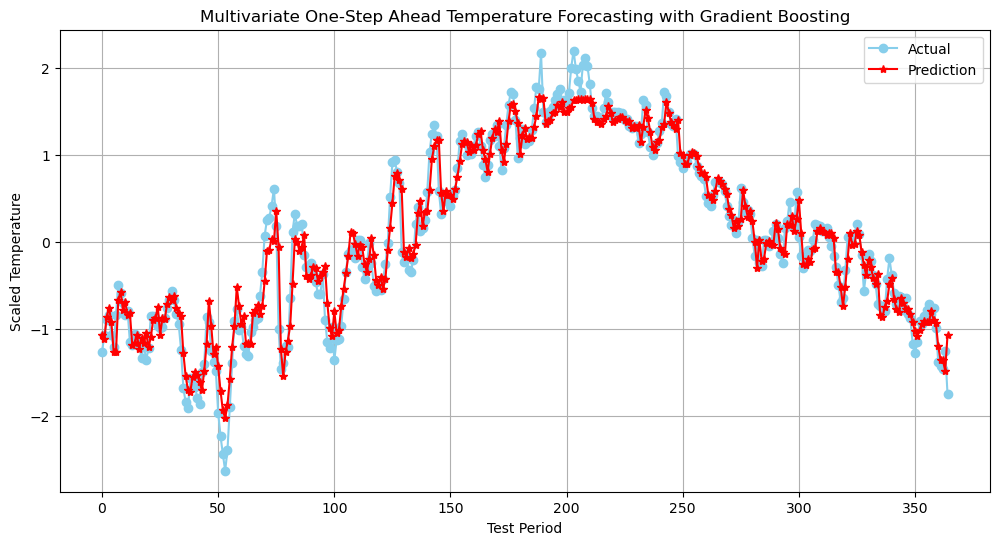

Multivariate Gradient Boosting R2 Score: 0.9572
CPU times: user 1min 5s, sys: 136 ms, total: 1min 5s
Wall time: 1min 5s


In [10]:
%%time

def preprocess_multivariate(data, lag=365, target_col=0):
    X = []
    y = []

    for i in range(len(data) - lag):
        X.append(data[i:i + lag].ravel())
        y.append(data[i + lag, target_col])

    return np.array(X), np.array(y)

X_multi, y_multi = preprocess_multivariate(
    df_scaled_multi,
    lag=LAG_DAYS,
    target_col=TARGET_COL)

print("X shape:", X_multi.shape)
print("y shape:", y_multi.shape)

X_train_multi = X_multi[:-TEST_DAYS]
y_train_multi = y_multi[:-TEST_DAYS]

X_test_multi = X_multi[-TEST_DAYS:]
y_test_multi = y_multi[-TEST_DAYS:]

mdl_gbr_multi = GradientBoostingRegressor(random_state=42)

mdl_gbr_multi.fit(X_train_multi, y_train_multi)

y_pred_multi = mdl_gbr_multi.predict(X_test_multi)

plot_predictions(
    y_test_multi,
    y_pred_multi,
    "Multivariate One-Step Ahead Temperature Forecasting with Gradient Boosting",
    "Scaled Temperature")

gbr_multi_r2 = r2_score(y_test_multi, y_pred_multi)
print("Multivariate Gradient Boosting R2 Score:", round(gbr_multi_r2, 4))

### 5.2. LSTM

X shape: (5475, 365, 3)
y shape: (5475,)
Train shape: (4599, 365, 3)
Validation shape: (511, 365, 3)
Test shape: (365, 365, 3)
Epoch 1/10
144/144 - 15s - 106ms/step - loss: 0.1140 - val_loss: 0.0576
Epoch 2/10
144/144 - 14s - 101ms/step - loss: 0.0648 - val_loss: 0.0464
Epoch 3/10
144/144 - 14s - 101ms/step - loss: 0.0566 - val_loss: 0.0439
Epoch 4/10
144/144 - 14s - 100ms/step - loss: 0.0542 - val_loss: 0.0451
Epoch 5/10
144/144 - 14s - 100ms/step - loss: 0.0533 - val_loss: 0.0458
Epoch 6/10
144/144 - 15s - 101ms/step - loss: 0.0526 - val_loss: 0.0467
Epoch 7/10
144/144 - 14s - 100ms/step - loss: 0.0523 - val_loss: 0.0476
Epoch 8/10
144/144 - 15s - 101ms/step - loss: 0.0520 - val_loss: 0.0482
Epoch 9/10
144/144 - 14s - 100ms/step - loss: 0.0518 - val_loss: 0.0489
Epoch 10/10
144/144 - 15s - 101ms/step - loss: 0.0516 - val_loss: 0.0496
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


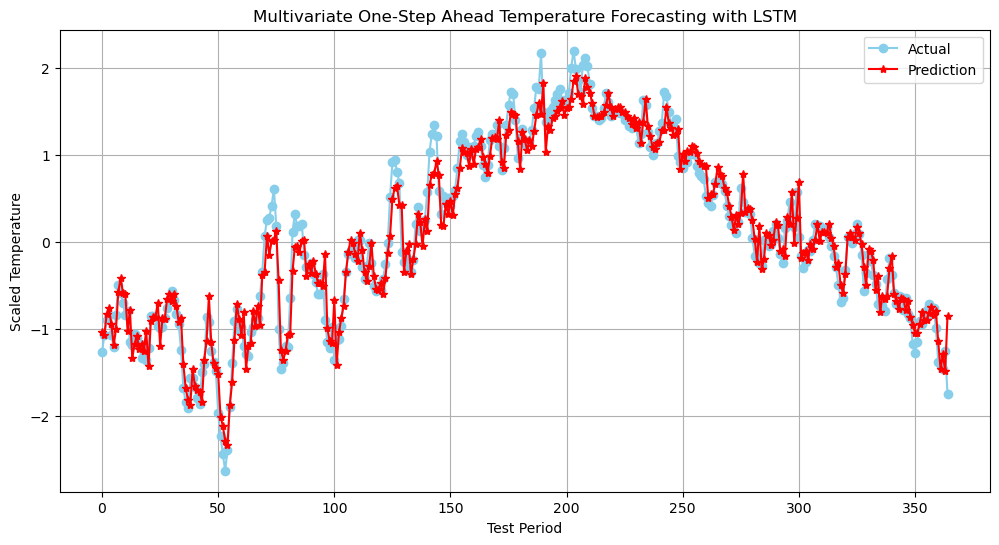

Multivariate LSTM R2 Score: 0.9597
CPU times: user 3min 36s, sys: 29.5 s, total: 4min 6s
Wall time: 2min 26s


In [11]:
%%time

def preprocess_multivariate_lstm(data, lag=365, target_col=0):
    X = []
    y = []

    for i in range(len(data) - lag):
        X.append(data[i:i + lag])
        y.append(data[i + lag, target_col])

    return np.array(X), np.array(y)

tf.random.set_seed(42)
np.random.seed(42)

X_lstm_multi, y_lstm_multi = preprocess_multivariate_lstm(
    df_scaled_multi,
    lag=LAG_DAYS,
    target_col=TARGET_COL)

print("X shape:", X_lstm_multi.shape)
print("y shape:", y_lstm_multi.shape)

X_train_full_lstm_multi = X_lstm_multi[:-TEST_DAYS]
y_train_full_lstm_multi = y_lstm_multi[:-TEST_DAYS]

X_test_lstm_multi = X_lstm_multi[-TEST_DAYS:]
y_test_lstm_multi = y_lstm_multi[-TEST_DAYS:]

val_size = int(len(X_train_full_lstm_multi) * VAL_RATIO)

X_train_lstm_multi = X_train_full_lstm_multi[:-val_size]
y_train_lstm_multi = y_train_full_lstm_multi[:-val_size]

X_val_lstm_multi = X_train_full_lstm_multi[-val_size:]
y_val_lstm_multi = y_train_full_lstm_multi[-val_size:]

print("Train shape:", X_train_lstm_multi.shape)
print("Validation shape:", X_val_lstm_multi.shape)
print("Test shape:", X_test_lstm_multi.shape)

mdl_lstm_multi = keras.Sequential([
    layers.Input(shape=X_train_lstm_multi.shape[1:]),
    layers.LSTM(128),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="linear")])

mdl_lstm_multi.compile(
    optimizer="adam",
    loss="mse")

history_lstm_multi = mdl_lstm_multi.fit(
    X_train_lstm_multi,
    y_train_lstm_multi,
    validation_data=(X_val_lstm_multi, y_val_lstm_multi),
    epochs=10,
    batch_size=32,
    verbose=2)

y_pred_lstm_multi = mdl_lstm_multi.predict(X_test_lstm_multi).ravel()

plot_predictions(
    y_test_lstm_multi,
    y_pred_lstm_multi,
    "Multivariate One-Step Ahead Temperature Forecasting with LSTM",
    "Scaled Temperature")

lstm_multi_r2 = r2_score(y_test_lstm_multi, y_pred_lstm_multi)
print("Multivariate LSTM R2 Score:", round(lstm_multi_r2, 4))

## 6. Feature Engineering + Tabular Modeling

**This part was especially important for this project.**

At this stage we will try **feature engineering**, which is commonly used in many time series problems. Features such as lag values, rolling statistics, and seasonal patterns are often helpful for capturing **hidden temporal behavior**.

This approach is especially common in areas such as **demand forecasting**, where manually engineered temporal features can significantly improve model performance.

At the same time, weather data already contains strong seasonal structure by nature. Because of that, I wanted to see if additional engineered features would still improve forecasting performance in this problem, or if the historical temperature patterns alone were already sufficient.

The final experiments were built using **feature engineered datasets** together with **Gradient Boosting** and **LightGBM** models.

### 6.1. Feature Engineering

In [12]:
%%time

df_fe = df_main.copy()
df_fe = df_fe.sort_values("date").reset_index(drop=True)
df_fe = df_fe[df_fe['date'].dt.year != 2026].copy()

df_fe['temp_mean_lag_1'] = df_fe['temp_mean'].shift(1)
df_fe['temp_mean_lag_7'] = df_fe['temp_mean'].shift(7)
df_fe['temp_mean_lag_30'] = df_fe['temp_mean'].shift(30)
df_fe['temp_mean_lag_365'] = df_fe['temp_mean'].shift(365)

df_fe['temp_min_lag_1'] = df_fe['temp_min'].shift(1)
df_fe['temp_min_lag_7'] = df_fe['temp_min'].shift(7)
df_fe['temp_min_lag_30'] = df_fe['temp_min'].shift(30)
df_fe['temp_min_lag_365'] = df_fe['temp_min'].shift(365)

df_fe['temp_max_lag_1'] = df_fe['temp_max'].shift(1)
df_fe['temp_max_lag_7'] = df_fe['temp_max'].shift(7)
df_fe['temp_max_lag_30'] = df_fe['temp_max'].shift(30)
df_fe['temp_max_lag_365'] = df_fe['temp_max'].shift(365)

df_fe['rolling_mean_7'] = df_fe['temp_mean'].shift(1).rolling(7).mean()
df_fe['rolling_mean_30'] = df_fe['temp_mean'].shift(1).rolling(30).mean()

df_fe['rolling_std_7'] = df_fe['temp_mean'].shift(1).rolling(7).std()
df_fe['rolling_std_30'] = df_fe['temp_mean'].shift(1).rolling(30).std()

df_fe['month'] = df_fe['date'].dt.month
df_fe['dayofyear'] = df_fe['date'].dt.dayofyear

df_fe['sin_dayofyear'] = np.sin(2 * np.pi * df_fe['dayofyear'] / 365)
df_fe['cos_dayofyear'] = np.cos(2 * np.pi * df_fe['dayofyear'] / 365)

FEATURES = [
    'temp_mean_lag_1',
    'temp_mean_lag_7',
    'temp_mean_lag_30',
    'temp_mean_lag_365',
    'temp_min_lag_1',
    'temp_min_lag_7',
    'temp_min_lag_30',
    'temp_min_lag_365',
    'temp_max_lag_1',
    'temp_max_lag_7',
    'temp_max_lag_30',
    'temp_max_lag_365',
    'rolling_mean_7',
    'rolling_mean_30',
    'rolling_std_7',
    'rolling_std_30',
    'month',
    'dayofyear',
    'sin_dayofyear',
    'cos_dayofyear'
]

TARGET = 'temp_mean'

df_fe = df_fe.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

X = df_fe[FEATURES]
y = df_fe[TARGET]

X_train = X.iloc[:-TEST_DAYS]
X_test = X.iloc[-TEST_DAYS:]

y_train = y.iloc[:-TEST_DAYS]
y_test = y.iloc[-TEST_DAYS:]



CPU times: user 5.31 ms, sys: 1.55 ms, total: 6.87 ms
Wall time: 6.06 ms


### 6.2. Gradient Boosting + Feature Engineered Dataset

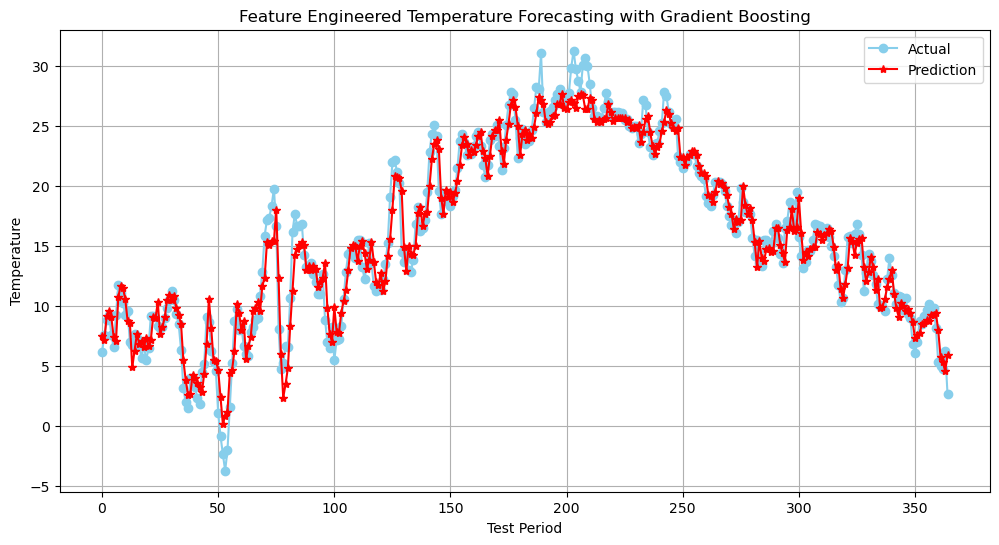

Feature Engineered Gradient Boosting R2 Score is: 0.9579
CPU times: user 1.35 s, sys: 4.83 ms, total: 1.36 s
Wall time: 1.36 s


In [13]:
%%time

mdl_gbr_fe = GradientBoostingRegressor(random_state=42)
mdl_gbr_fe.fit(X_train, y_train)
y_pred_gbr_fe = mdl_gbr_fe.predict(X_test)
gbr_fe_r2 = r2_score(y_test, y_pred_gbr_fe)

plot_predictions(
    y_test.values,
    y_pred_gbr_fe,
    "Feature Engineered Temperature Forecasting with Gradient Boosting",
    "Temperature")

print("Feature Engineered Gradient Boosting R2 Score is:", round(gbr_fe_r2, 4))

### 6.3. LightGBM + Feature Engineered Dataset

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000326 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4819
[LightGBM] [Info] Number of data points in the train set: 5110, number of used features: 20
[LightGBM] [Info] Start training from score 15.371526


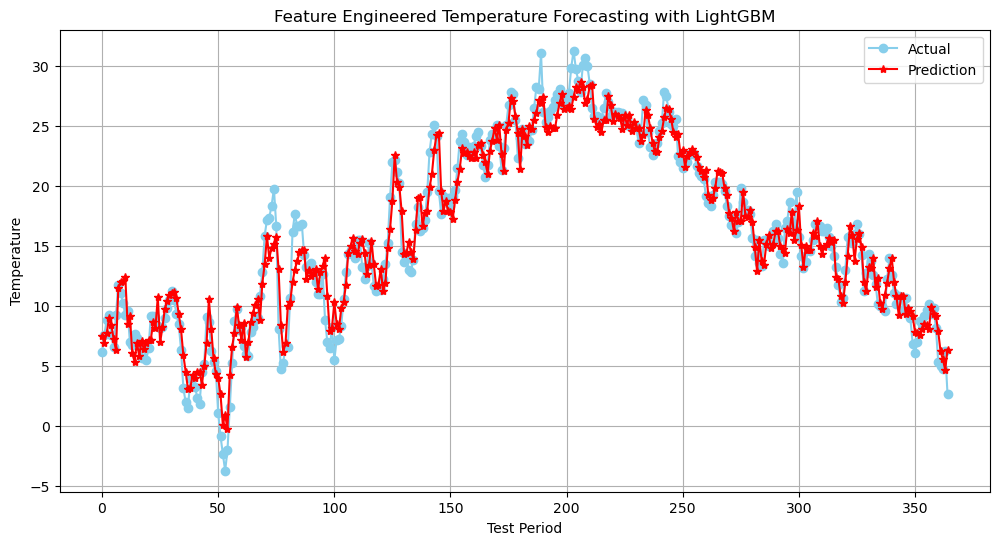

LightGBM R2 Score is: 0.9548
CPU times: user 2.09 s, sys: 4.78 s, total: 6.88 s
Wall time: 3.07 s


In [14]:
%%time

mdl_lgbm = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42)

mdl_lgbm.fit(X_train, y_train)
y_pred_lgbm = mdl_lgbm.predict(X_test)
lgbm_r2 = r2_score(y_test, y_pred_lgbm)

plot_predictions(
    y_test.values,
    y_pred_lgbm,
    "Feature Engineered Temperature Forecasting with LightGBM",
    "Temperature")

print("LightGBM R2 Score is:", round(lgbm_r2, 4))

## 7. Compare Results

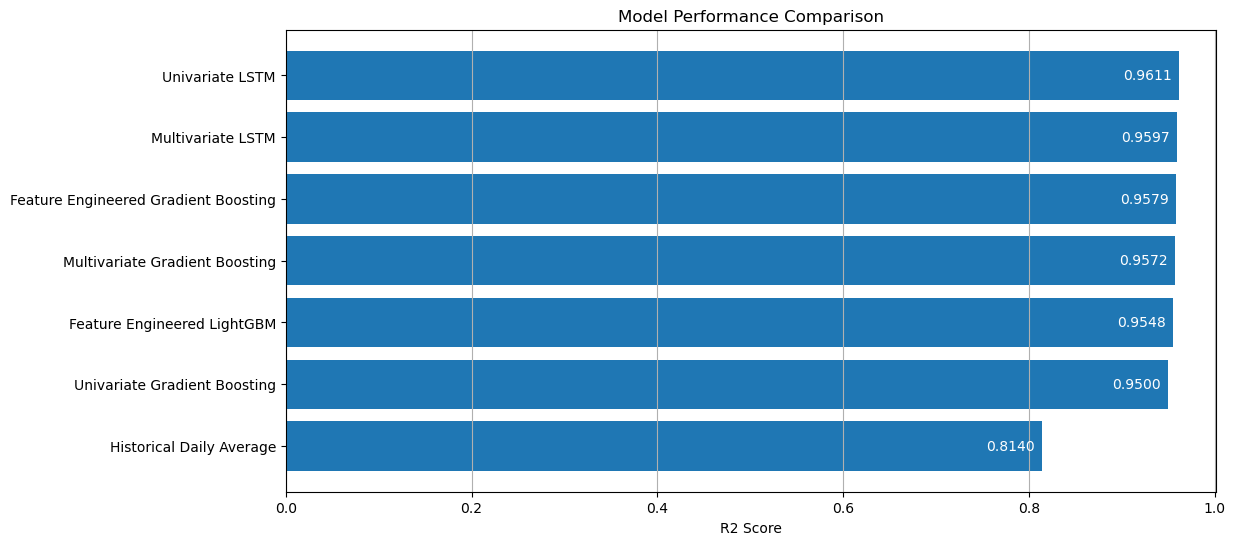

In [15]:
model_results = pd.DataFrame({
    "Model": [
        "Historical Daily Average",
        "Univariate Gradient Boosting",
        "Univariate LSTM",
        "Multivariate Gradient Boosting",
        "Multivariate LSTM",
        "Feature Engineered Gradient Boosting",
        "Feature Engineered LightGBM"],
    "R2 Score": [
        daily_avg_r2,
        gbr_uni_r2,
        lstm_uni_r2,
        gbr_multi_r2,
        lstm_multi_r2,
        gbr_fe_r2,
        lgbm_r2]})

model_results = model_results.sort_values(
    "R2 Score",
    ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    model_results["Model"],
    model_results["R2 Score"])

plt.title("Model Performance Comparison")
plt.xlabel("R2 Score")

max_score = model_results["R2 Score"].max()

for bar in bars:
    width = bar.get_width()

    plt.text(
        width - 0.06,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
        color="white")

plt.xlim(0, max_score + 0.04)

plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()

## 8. Conclusion


This project compared multiple forecasting approaches using daily weather data from **Kocaeli, Turkey**.

The baseline method based on historical daily averages achieved an R2 score of **0.8140**. After applying machine learning and deep learning models, forecasting performance increased significantly.

The best result was achieved by the **Univariate LSTM** model with an R2 score of **0.9611**. However, the overall differences between the advanced models remained relatively small. From a real-world perspective, these performance gaps are not dramatic, especially when factors such as training time, model complexity, and implementation cost are considered.

The feature engineering stage also improved the performance of tabular models. Lag features, rolling statistics, and seasonal transformations helped the models capture temporal behavior more effectively.

Overall, the results showed that historical temperature patterns already contain strong predictive information, and several different forecasting approaches can produce highly accurate results on this dataset.

## 9. Where This Approach Can Be Applied

Similar approaches can also be applied to many other **time series problems**, including:

* demand forecasting
* sales forecasting
* energy consumption prediction
* production planning
* inventory forecasting
* traffic forecasting
* sensor data analysis
* predictive maintenance
* financial time series analysis
* website traffic forecasting